![spreedsheet_finance](spreedsheet_finance.jpg)

Your project is centered around developing a reinforcement learning (RL) simulation for stock trading in Python. This initiative is spearheaded by Quantum Trading, a fictional but ambitious trading firm looking to leverage cutting-edge machine learning techniques to gain a competitive edge in the financial markets. Quantum Trading is a small but highly specialised team of financial analysts, data scientists, and software engineers who are passionate about transforming the way trading decisions are made.

In the fast-paced world of financial markets, staying ahead of the curve is crucial. Traditional trading strategies, while effective, often rely on historical data and predefined rules that may not adapt quickly to changing market conditions. Reinforcement learning, a subfield of machine learning where an agent learns to make decisions by interacting with an environment, offers a promising alternative. It allows the trading algorithms to learn and adapt in real-time, improving their performance as they gain more experience.

By engaging with this project, you will gain valuable insights into the dynamic world of algorithmic trading and enhance your skill set in data science, finance, and machine learning. Remember, the journey of learning and experimentation is as important as the results. Good luck, and may your trading algorithms be ever profitable!

## The Data
The provided data `AAPL.csv` contains historical prices for AAPL (the ticker symbol for Apple Inc) and you will be using this in your model. It has been loaded for you already in the sample code below and contains two columns, described below.

| Column | Description |
|--------|-------------|
|`Date`    | The date corresponding to the closing price              |
|`Close`   | The closing price of the security on the given date      |

_**Disclaimer: This project is for educational purposes only. It is not financial advice, and should not be understood or construed as, financial advice.**_

In [47]:
# Make sure to run this cell to use gymnasium gym-anytrading stable-baselines3
!pip install gymnasium gym-anytrading stable-baselines3

Defaulting to user installation because normal site-packages is not writeable


In [48]:
# Import required packages
# Note that gym-anytrading is a gym environment specific for trading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import gym_anytrading
from gym_anytrading.envs import Actions
from stable_baselines3 import PPO

# Load the data provided. this is the stock price of APPLE 
data = pd.read_csv("AAPL.csv", parse_dates=True, index_col='Date')

# Set window size (lookback window), start and end index of data
window_size = 10
start_index = window_size
end_index = len(data)

# Create the environment using the pre-built 'stocks-v0', passing in the data loaded above
# window_size is how far the environment can look back at each step
# frame_bound is the bounding box of the environment, the size of our data
env = gym.make('stocks-v0', df=data, window_size=window_size, frame_bound=(start_index, end_index))

# Ovservation Space defines the ranges of values we can use as states in environment.
# here we use [-1e10, 1e10] as the range, we also define that each stae a 10 by 2 matrix
# where 10 is the window size of data points, and 2 features refer to the current price and 
# the difference between current and last prices, respectively
print("Observation Space:", env.observation_space)

# Initialise cash balance tracking and other variables
balance = 100000
balance_history = [balance]
shares_held = 0
action_stats = {Actions.Sell: 0, Actions.Buy: 0}
observation, info = env.reset(seed=2024)

Observation Space: Box(-10000000000.0, 10000000000.0, (10, 2), float32)


In [49]:
# we only have two actions, sell or buy where we use 10% of the balance to buy in Actions.Buy and we # sell all in Actions.Sell
list(Actions)

[<Actions.Sell: 0>, <Actions.Buy: 1>]

In [50]:
observation

array([[ 4.947143e+00,  7.714300e-02],
       [ 5.083571e+00,  1.364280e-01],
       [ 5.081071e+00, -2.500000e-03],
       [ 5.245714e+00,  1.646430e-01],
       [ 5.268571e+00,  2.285700e-02],
       [ 5.419643e+00,  1.510720e-01],
       [ 5.461071e+00,  4.142800e-02],
       [ 5.411071e+00, -5.000000e-02],
       [ 5.597857e+00,  1.867860e-01],
       [ 5.636429e+00,  3.857200e-02]], dtype=float32)

In [51]:
# stock price of APPLE for each close date
data.head()

,Close
Date,
2009-07-09,4.870000
2009-07-10,4.947143
2009-07-13,5.083571
2009-07-14,5.081071
2009-07-15,5.245714


In [52]:
# Start coding here by training the PPO model
# Use as many cells as you need
total_timestamps = 10000

# use 10% of balance for trading when Action is Buy
trade_perct = 0.1

model = PPO("MlpPolicy", env=env, verbose=0)
model.learn(total_timesteps=total_timestamps)

In [53]:
print(f"prices={env.unwrapped.prices}")
print(f"current_tick={env.unwrapped._current_tick}")
print(f"current_price={env.unwrapped.prices[env.unwrapped._current_tick]}")

prices=[  4.87       4.947143   5.083571 ... 221.55     226.34     227.82    ]
current_tick=2724
current_price=74.38999938964844


In [54]:
Actions(1)

<Actions.Buy: 1>

In [55]:
# go through one episode to collect balance history

observation, info = env.reset(seed=2024)

step = 0
while True:
    action, _state = model.predict(observation)
    next_state, reward, terminated, truncated, _ = env.step(action)
    current_price = env.unwrapped.prices[env.unwrapped._current_tick]

    if action == Actions.Sell.value:
        balance += shares_held * current_price
        shares_held = 0
    elif action == Actions.Buy.value:
        buy_amount = balance * trade_perct
        shares_held += buy_amount / current_price
        balance -= buy_amount

    if terminated or truncated:
        break
        
    step += 1
    action_stats[Actions(action)] += 1
    balance_history.append(balance)
env.close()    

if shares_held > 0:
    balance += shares_held * current_price
    shares_heldl = 0
    action_stats[Actions(Actions.Sell.value)] += 1
    balance_history.append(balance)      

In [56]:
len(balance_history)

3763

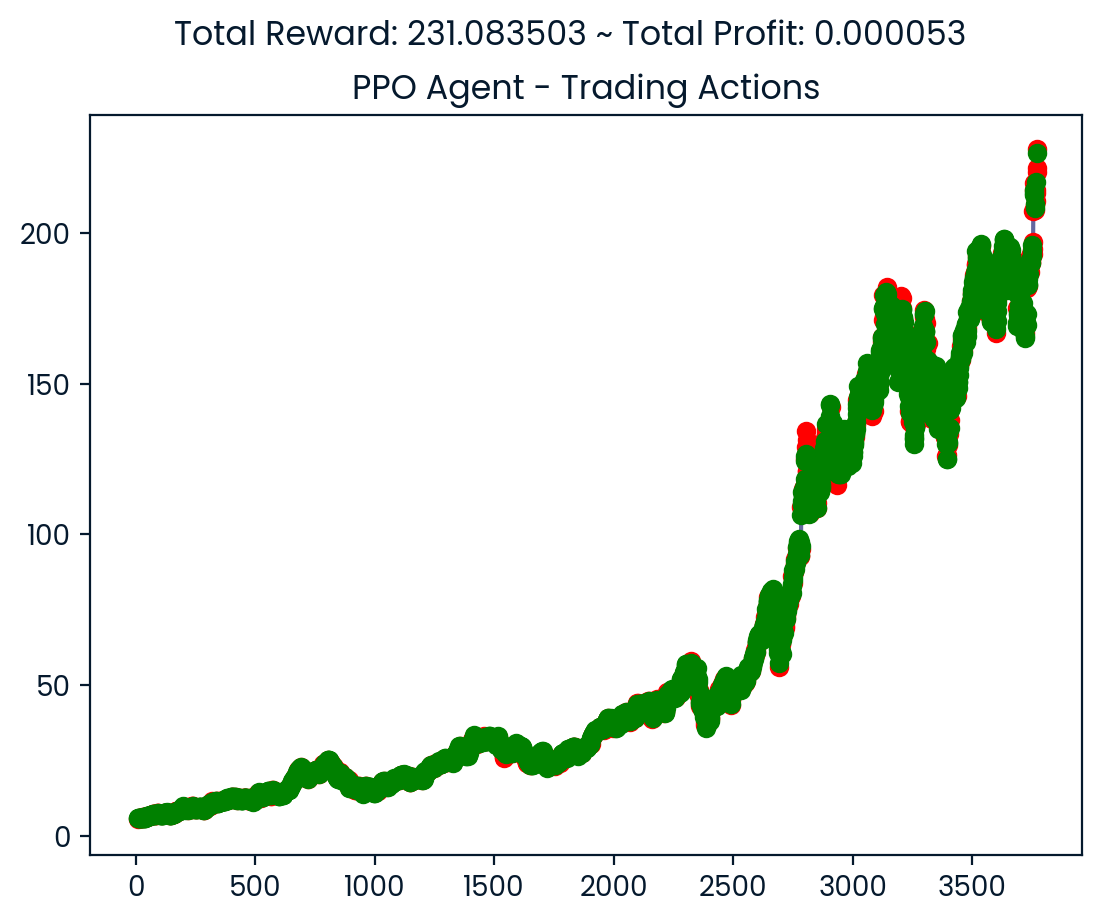

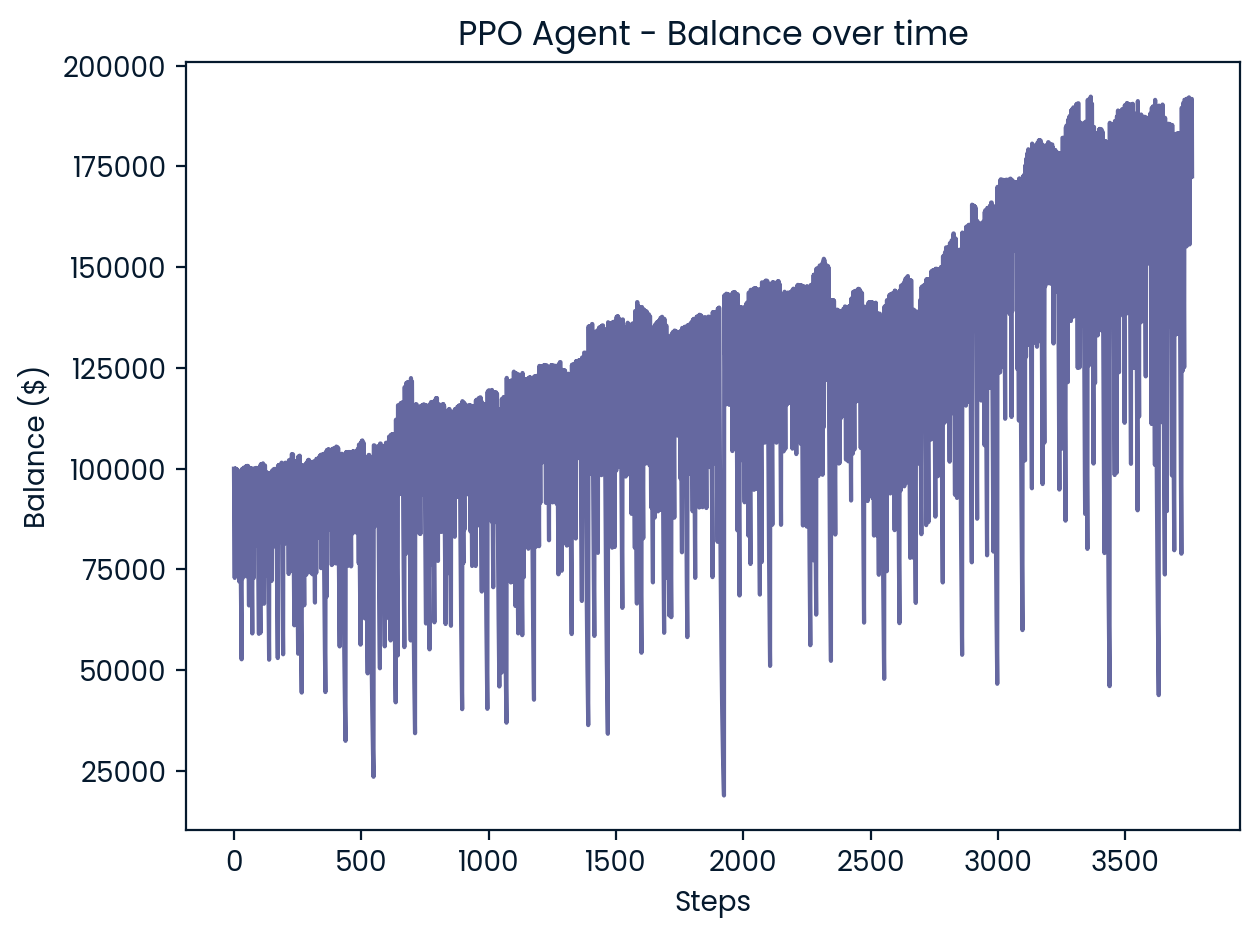

In [57]:
# Create your two charts below. Note, do not change the fig and ax variable names.

# Chart 1, a plot showing trading actions
fig, ax = plt.subplots()
env.unwrapped.render_all()
ax.set_title("PPO Agent - Trading Actions")
plt.show()

# Chart 2, a plot of the balance_history over time
fig2, ax2 = plt.subplots()
ax2.plot(balance_history)
ax2.set_title("PPO Agent - Balance over time")
ax2.set_xlabel("Steps")
ax2.set_ylabel("Balance ($)")
fig2.tight_layout()
plt.show()
